<a href="https://colab.research.google.com/github/larissaorsomarso/mvp-cep-concreto/blob/main/MVP_CEP_Concreto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dados carregados com sucesso!


/tmp/ipykernel_2074/2634227341.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='categoria_resistencia', y='resistencia', data=df, ax=axes[1], palette='Set2')
/tmp/ipykernel_2074/2634227341.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Comum (<40)', 'Alta Res. (>=40)'])


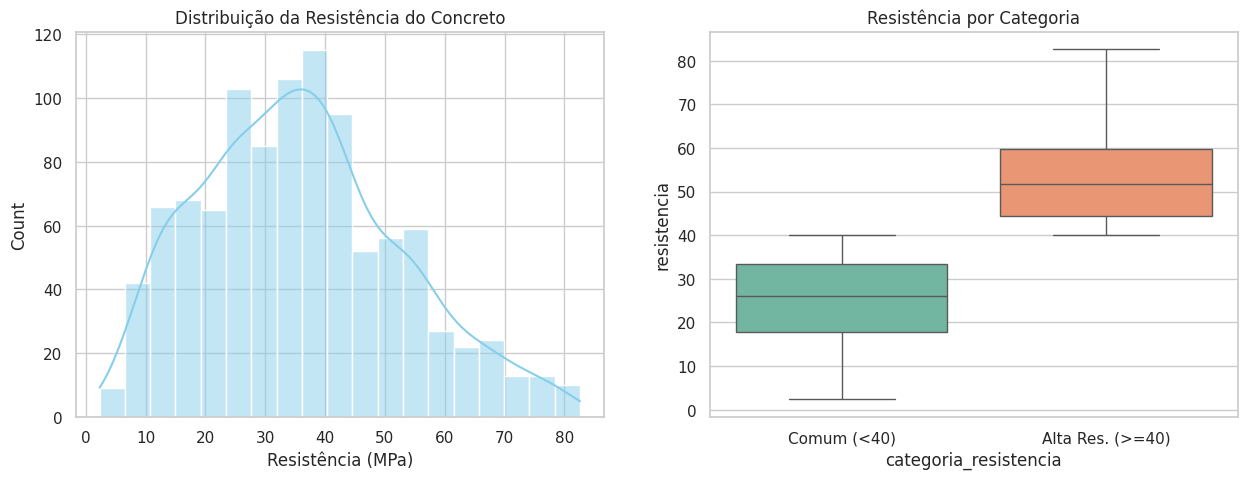

Dados divididos com sucesso!
Amostras de Treino: 721
Amostras de Teste: 309
=== RESULTADOS INICIAIS ===

Acurácia Árvore de Decisão: 86.41%
Acurácia Regressão Logística: 80.26%

--- Matriz de Confusão (Árvore) ---
[[184  17]
 [ 25  83]]

--- Matriz de Confusão (Logística) ---
[[179  22]
 [ 39  69]]


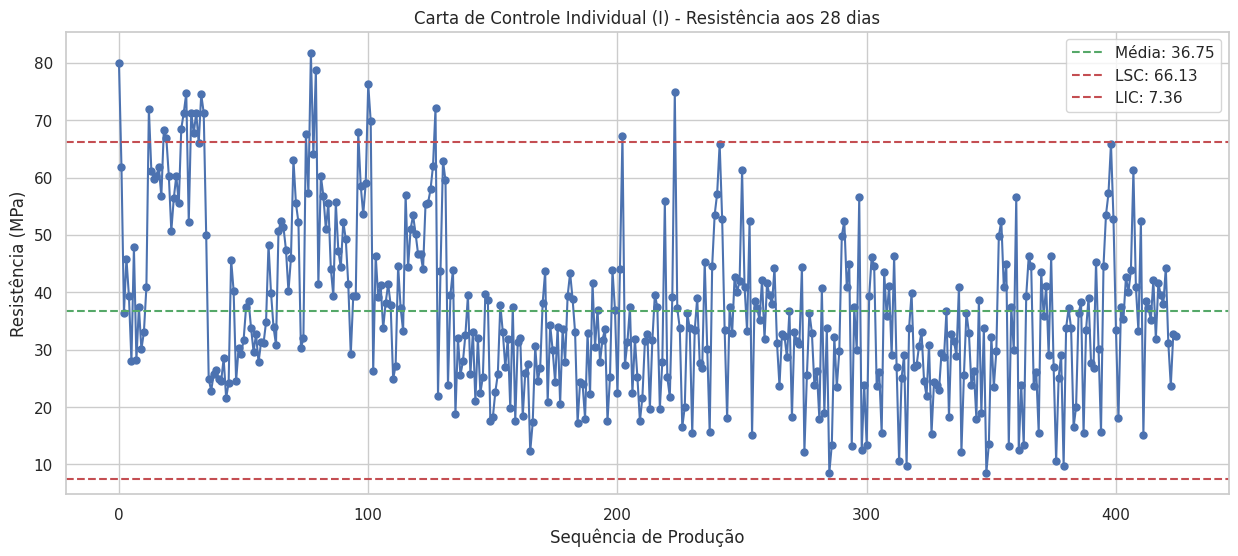

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações para os gráficos aparecerem no notebook
%matplotlib inline

# URL do dataset no repositório UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls"

# Carregando os dados (requer a biblioteca 'xlrd')
try:
    df = pd.read_excel(url)
    print("Dados carregados com sucesso!")
except:
    print("Erro ao carregar. Certifique-se de que a biblioteca 'xlrd' está instalada: !pip install xlrd")

# Renomeando colunas para facilitar a manipulação
df.columns = ['cimento', 'escoria', 'cinza_volante', 'agua', 'superplastificante',
              'agregado_graudo', 'agregado_miudo', 'idade', 'resistencia']

# Criando a variável alvo binária conforme o planejamento (40 MPa como limiar)
df['categoria_resistencia'] = df['resistencia'].apply(lambda x: 1 if x >= 40 else 0)

# Visualizando as primeiras linhas
df.head()

import seaborn as sns
import matplotlib.pyplot as plt

# Configurando o estilo visual
sns.set_theme(style="whitegrid")

# Criando uma figura com dois gráficos (lado a lado)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Histograma da Resistência
sns.histplot(df['resistencia'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribuição da Resistência do Concreto')
axes[0].set_xlabel('Resistência (MPa)')

# 2. Boxplot por Categoria (Comum vs Alta Resistência)
sns.boxplot(x='categoria_resistencia', y='resistencia', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Resistência por Categoria')
axes[1].set_xticklabels(['Comum (<40)', 'Alta Res. (>=40)'])

plt.show()

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Selecionando as variáveis de entrada (X) e o alvo (y)
# Vamos usar as proporções dos insumos e a idade para prever a categoria
X = df.drop(['resistencia', 'categoria_resistencia'], axis=1)
y = df['categoria_resistencia']

# 2. Divisão em Treino (70%) e Teste (30%) conforme seu plano
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Normalização (Escalonamento) - Importante para modelos como Regressão Logística
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Dados divididos com sucesso!")
print(f"Amostras de Treino: {len(X_train)}")
print(f"Amostras de Teste: {len(X_test)}")

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Instanciando os modelos
modelo_arvore = DecisionTreeClassifier(random_state=42)
modelo_logistica = LogisticRegression(random_state=42)

# 2. Treinamento
modelo_arvore.fit(X_train, y_train) # Árvore não precisa obrigatoriamente de escala
modelo_logistica.fit(X_train_scaled, y_train) # Logística precisa dos dados escalonados

# 3. Predições
pred_arvore = modelo_arvore.predict(X_test)
pred_logistica = modelo_logistica.predict(X_test_scaled)

# 4. Exibindo os Resultados
print("=== RESULTADOS INICIAIS ===\n")

print(f"Acurácia Árvore de Decisão: {accuracy_score(y_test, pred_arvore):.2%}")
print(f"Acurácia Regressão Logística: {accuracy_score(y_test, pred_logistica):.2%}")

print("\n--- Matriz de Confusão (Árvore) ---")
print(confusion_matrix(y_test, pred_arvore))

print("\n--- Matriz de Confusão (Logística) ---")
print(confusion_matrix(y_test, pred_logistica))

# 1. Filtrando apenas os ensaios de 28 dias conforme o plano
df_28 = df[df['idade'] == 28].copy().reset_index()

# 2. Cálculos para a Carta I (Individual)
media_x = df_28['resistencia'].mean()
df_28['MR'] = df_28['resistencia'].diff().abs() # Amplitude Móvel
media_mr = df_28['MR'].mean()

# Constante d2 para n=2 é 1.128
lsc = media_x + 3 * (media_mr / 1.128)
lic = media_x - 3 * (media_mr / 1.128)

# 3. Plotando a Carta de Controle Individual
plt.figure(figsize=(15, 6))
plt.plot(df_28['resistencia'], marker='o', color='b', linestyle='-', markersize=5)
plt.axhline(media_x, color='g', linestyle='--', label=f'Média: {media_x:.2f}')
plt.axhline(lsc, color='r', linestyle='--', label=f'LSC: {lsc:.2f}')
plt.axhline(lic, color='r', linestyle='--', label=f'LIC: {lic:.2f}')

plt.title('Carta de Controle Individual (I) - Resistência aos 28 dias')
plt.xlabel('Sequência de Produção')
plt.ylabel('Resistência (MPa)')
plt.legend()
plt.show()